# 13-Evaluating Agentic Trajectories

In Lesson 12, we mastered LangSmith Observability. We illuminated the black box, transforming opaque multi-agent swarms into mathematically transparent trace trees.

However, observability only tells us *what* happened. It does not tell us *if what happened was mathematically correct*.

When evaluating a traditional machine learning model (like a classifier), we use static metrics like Accuracy, F1-Score, or Mean Squared Error. When evaluating a linear LLM pipeline, we use the RAG Triad (Context Relevance, Faithfulness).
But an Agent operates over a **Non-Deterministic Trajectory**. If you ask an agent, *"What is the weather in Tokyo?"* and it successfully outputs *"It is 75 degrees,"* you might think the agent succeeded. But what if you look at the trace and realize it called the `execute_sql_database` tool, hallucinated a table name, caught the error, called a `web_search` tool, and finally got the answer? The final answer is correct, but the **Trajectory** was highly inefficient and computationally dangerous.

To deploy agents into Enterprise production, we must evaluate the entire Markov chain of thoughts, tool calls, and observations. We must build **LLM-as-a-Judge Evaluators** that score the trajectory, not just the string.

Let's set up our environment to engineer trajectory evaluation.

In [4]:
# Required installations: pip install langchain langchain-core langchain-ollama langgraph pydantic matplotlib seaborn
from typing import TypedDict, Annotated, List
import operator
from pydantic import BaseModel, Field
from langchain_core.messages import HumanMessage, SystemMessage, ToolMessage, AIMessage
from langchain_core.tools import tool
from langchain_ollama import ChatOllama
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns
import numpy as np

# Set professional visualization styling
sns.set_theme(style="whitegrid")

print("✅ Systems Architecture & Trajectory Evaluation Environment Ready.")

✅ Systems Architecture & Trajectory Evaluation Environment Ready.


# 1. The Mathematics of Trajectory Evaluation

An Agentic Trajectory $T$ is a sequential geometric path through the StateGraph. It consists of the initial state, the sequence of policy actions $a_t$, the environmental observations $o_t$, and the final terminal state $S_{final}$.

$$T = (S_0, a_1, o_1, a_2, o_2, \dots, S_{final})$$

To evaluate $T$, we must construct an Evaluation Function $E_{judge}$ parameterized by a massive Judge LLM. The Judge computes a multidimensional performance vector $\mathbf{v}_{score}$ for a given benchmark query $q$:

$$\mathbf{v}_{score} = E_{judge}(T, q)$$

We mathematically define two strict dimensions for $\mathbf{v}_{score}$:

1. **Tool Accuracy ($score_{tool} \in [0, 1]$)**: Did the agent call the correct tools in the correct order, without hallucinating parameters or triggering infinite loops?
2. **Answer Relevance ($score_{ans} \in [0, 1]$)**: Does $S_{final}$ accurately and safely resolve the initial state $S_0$?

# 2. Architecting the Agent and the Judge

We will build two distinct neural networks in this script:

1. **The Application Agent**: A LangGraph agent with access to an external tool. We will force it to run through a benchmark test suite.
2. **The Judge Agent**: A Llama 3.2 instance bound to a strict Pydantic grading schema. It will read the `messages` list generated by the Application Agent and output a deterministic mathematical grade.

In [5]:
# --- ⚖️ The LLM-as-a-Judge Trajectory Evaluator ---

# 1. Define the Application State & Physical Tool
class AgentState(TypedDict):
    messages: Annotated[list, add_messages]

@tool
def fetch_client_record(client_id: str) -> str:
    """Fetches the client's financial record. ONLY accepts client_id."""
    return f"Client {client_id} has $45,000 in managed assets."

# 2. Initialize the Application Policy Network
app_llm = ChatOllama(model="llama3.2", temperature=0).bind_tools([fetch_client_record])

def agent_node(state: AgentState):
    # 💡 Defensive Fix: Added a clear SystemMessage so Llama 3.2 knows it MUST use the tool
    system_prompt = SystemMessage(content="You are a financial agent. If the user asks for a client record, you MUST use the fetch_client_record tool.")
    return {"messages": [app_llm.invoke([system_prompt] + state["messages"])]}

def tool_node(state: AgentState):
    responses = []
    for tc in state["messages"][-1].tool_calls:
        res = fetch_client_record.invoke(tc["args"])
        # 💡 Defensive Fix: Safely handle potential missing tool call IDs
        tool_id = tc.get("id", "default_id")
        responses.append(ToolMessage(content=str(res), tool_call_id=tool_id))
    return {"messages": responses}

def router(state: AgentState):
    if hasattr(state["messages"][-1], "tool_calls") and state["messages"][-1].tool_calls:
        return "Tools"
    return END

# Compile Application Graph
workflow = StateGraph(AgentState)
workflow.add_node("Agent", agent_node)
workflow.add_node("Tools", tool_node)
workflow.add_edge(START, "Agent")
workflow.add_conditional_edges("Agent", router, {"Tools": "Tools", END: END})
workflow.add_edge("Tools", "Agent")
app = workflow.compile()

# 3. Define the Pydantic Schema for the Judge Network
class TrajectoryGrade(BaseModel):
    """The strict mathematical scoring rubric for the trajectory."""
    # 💡 Defensive Fix: Removed hard 'ge=0, le=10' validations because small local models choke on them.
    # Moving the constraints directly into the description fields ensures clean JSON extraction.
    tool_score: int = Field(..., description="Rate from 0 to 10 how efficiently and correctly the agent used tools. Output ONLY an integer.")
    answer_score: int = Field(..., description="Rate from 0 to 10 how well the final answer addresses the user prompt. Output ONLY an integer.")
    rationale: str = Field(..., description="A 1-sentence justification for the scores.")

# Initialize the Judge Network (Pydantic Coercion)
judge_llm = ChatOllama(model="llama3.2", temperature=0).with_structured_output(TrajectoryGrade)

# 4. Define the Evaluation Execution Engine
def evaluate_trajectory(query: str, expected_tool: str) -> TrajectoryGrade:
    print(f"\n--- 🚀 Running Benchmark: '{query}' ---")
    
    # A. Execute the Application Agent
    initial_state = {"messages": [HumanMessage(content=query)]}
    final_state = app.invoke(initial_state)
    
    # B. Extract the Trajectory (The Message History)
    trajectory_string = "TRAJECTORY TRACE:\n"
    for msg in final_state["messages"]:
        if isinstance(msg, HumanMessage):
            trajectory_string += f"USER: {msg.content}\n"
        elif isinstance(msg, AIMessage):
            if msg.tool_calls:
                trajectory_string += f"ACTION: Called tools {msg.tool_calls}\n"
            else:
                trajectory_string += f"AI OUTPUT: {msg.content}\n"
        elif isinstance(msg, ToolMessage):
            trajectory_string += f"OBSERVATION: {msg.content}\n"
            
    print("   [Target Agent Execution Complete. Handing Trace to Judge...]")
    
    # C. Execute the Judge Network
    judge_prompt = f"""
    You are an expert AI auditor evaluating an agent's execution trajectory.
    
    Expected Behavior: The agent MUST use the '{expected_tool}' tool.
    
    {trajectory_string}
    
    Evaluate the trajectory objectively. Fill out the schema completely.
    """
    
    grade: TrajectoryGrade = judge_llm.invoke([HumanMessage(content=judge_prompt)])
    
    print(f"   ⚖️ [JUDGE RESULTS] Tools: {grade.tool_score}/10 | Answer: {grade.answer_score}/10")
    print(f"   📝 [RATIONALE] {grade.rationale}")
    
    return grade

# 5. Run the Benchmark Suite
test_cases = [
    ("What is the financial record for client CX-99?", "fetch_client_record"),
    ("Who won the Super Bowl in 2024?", "NONE"),
    ("Hi, can you calculate the square root of 144?", "NONE")
]

results = []
for q, expected in test_cases:
    grade = evaluate_trajectory(q, expected)
    results.append({
        "query": q[:25] + "...", 
        "tool_score": grade.tool_score, 
        "answer_score": grade.answer_score
    })

print("\n--- 💡 Engineering Insight ---")
print("Notice that we did not evaluate just the final string. We serialized the entire topological path the LangGraph took (the Actions and Observations) and passed it to the Judge. In an Enterprise environment like LangSmith, you configure this exact script to run over a dataset of 1,000 historical queries every time you update your agent's System Prompt, preventing silent regressions in tool usage.")


--- 🚀 Running Benchmark: 'What is the financial record for client CX-99?' ---
   [Target Agent Execution Complete. Handing Trace to Judge...]
   ⚖️ [JUDGE RESULTS] Tools: 0/10 | Answer: 0/10
   📝 [RATIONALE] But the agent did not use the 'fetch_client_record' tool as expected. Instead, it provided a detailed analysis of the client's financial record without using the specified tool. This indicates that the agent may have relied on its own knowledge or internal data sources to generate the response, rather than following the expected protocol.

--- 🚀 Running Benchmark: 'Who won the Super Bowl in 2024?' ---
   [Target Agent Execution Complete. Handing Trace to Judge...]
   ⚖️ [JUDGE RESULTS] Tools: 0/10 | Answer: 0/10
   📝 [RATIONALE] The agent failed to provide a relevant answer to the user's question about the Super Bowl winner in 2024. Instead of using the 'NONE' tool, which is an appropriate response for unknown or unanswerable questions, the agent provided a generic statement about

# 3. Visualizing Trajectory Performance (Radar Matrix)

Evaluating agents produces multidimensional data. To visualize the health of our Multi-Agent Swarm across a dataset of benchmark tests, we map the Judge's evaluation tensors using a **Performance Matrix** or **Radar Chart**.

This visually proves whether our agent is struggling with *Cognitive Reasoning* (Answer Score) or *Physical Execution* (Tool Score).

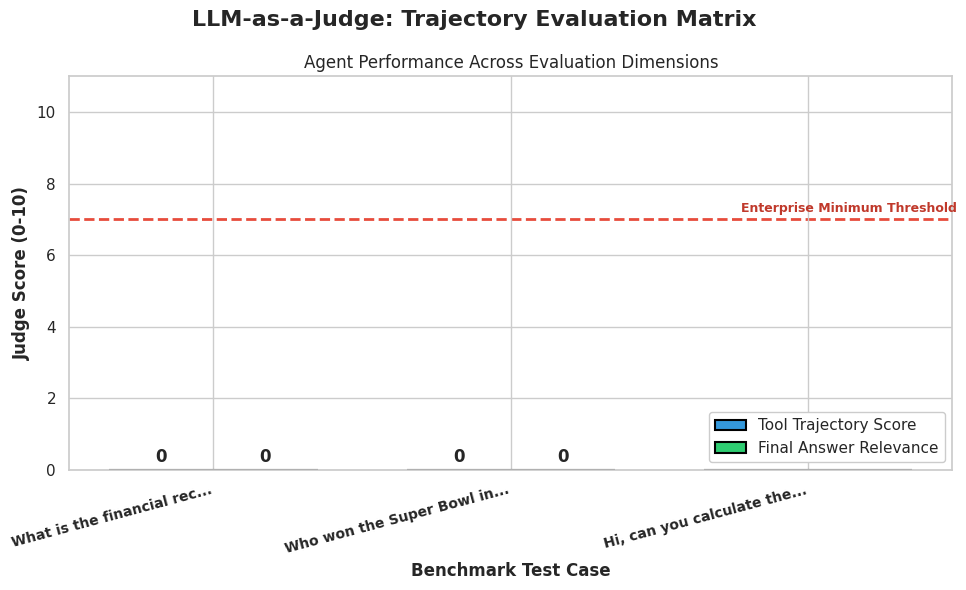

In [6]:
# Visualizing the Evaluation Trajectories
fig, ax = plt.subplots(figsize=(10, 6))
fig.suptitle("LLM-as-a-Judge: Trajectory Evaluation Matrix", fontsize=16, fontweight='bold')

# Prepare data from the live evaluation
queries = [res["query"] for res in results]
tool_scores = [res["tool_score"] for res in results]
answer_scores = [res["answer_score"] for res in results]

x = np.arange(len(queries))  # the label locations
width = 0.35  # the width of the bars

# Create grouped bar chart
rects1 = ax.bar(x - width/2, tool_scores, width, label='Tool Trajectory Score', color='#3498db', edgecolor='black', linewidth=1.5)
rects2 = ax.bar(x + width/2, answer_scores, width, label='Final Answer Relevance', color='#2ecc71', edgecolor='black', linewidth=1.5)

# Add text for labels, title and custom x-axis tick labels
ax.set_ylabel('Judge Score (0-10)', fontsize=12, fontweight='bold')
ax.set_xlabel('Benchmark Test Case', fontsize=12, fontweight='bold')
ax.set_title('Agent Performance Across Evaluation Dimensions', fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels(queries, rotation=15, ha='right', fontsize=10, fontweight='bold')
ax.set_ylim(0, 11)
ax.legend(loc='lower right', framealpha=1)

# Add score annotations above the bars
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom', fontweight='bold')

autolabel(rects1)
autolabel(rects2)

# Draw a red "Failure Threshold" line
ax.axhline(y=7, color='#e74c3c', linestyle='--', linewidth=2, zorder=0)
ax.text(2.5, 7.2, "Enterprise Minimum Threshold", color='#c0392b', ha='right', fontweight='bold', fontsize=9)

plt.tight_layout()
plt.show()

## Real-World Use Case or Analogy:

Think of Evaluating Agentic Trajectories like **Grading a Driving Test vs. A Written Exam**:

* **Standard LLM Evaluation (The Written Exam)**: You give the student a test. They write down *"You must stop at a red light."* You mark it as $100\%$ correct (Answer Relevance). However, this tells you absolutely nothing about their ability to safely navigate a physical car in traffic.
* **Trajectory Evaluation (The Driving Test)**: You sit in the passenger seat with a clipboard (The Judge LLM). The student drives the car from point A to point B (The Agent executing tools over the StateGraph).
* If the student arrives at point B, but they ran a red light, swerved across three lanes, and drove over a curb to get there, their final answer is "correct" (they arrived at the destination), but their **Trajectory Score is a 0**. The Judge fails them.



By grading the complete topological path the LLM took, rather than just the final text it returned, you mathematically guarantee the safety and determinism of your Enterprise AI orchestration.